# 05 — Chunked QLoRA Workflow

This notebook mirrors `04_unified_workflow.ipynb` but adds a third method, `qlora_chunked`, which streams the NF4 base-weight matmul one row-chunk at a time via a custom autograd Function. The full fp16 weight is never materialized in forward and is not retained for backward, so peak VRAM should drop below plain LoRA instead of exceeding it.

We re-run `lora`, `qlora`, and `qlora_chunked` on the same OASST1 splits and compare the three on VRAM, throughput, training time, and eval loss.

In [1]:
!git clone https://github.com/khanzaifa37/Quantized-LoRA.git
%cd ./Quantized-LoRA/

Cloning into 'Quantized-LoRA'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 95 (delta 40), reused 74 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 139.38 KiB | 2.73 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/Quantized-LoRA


In [2]:
from pathlib import Path
import sys
import torch

PROJECT_ROOT = Path("/content/qLoRA").resolve()
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Project root: /content/Quantized-LoRA
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [3]:
import subprocess

subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "origin", "main"], check=False)


CompletedProcess(args=['git', '-C', '/content/Quantized-LoRA', 'pull', 'origin', 'main'], returncode=0)

In [4]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")])


0

## 1. Prepare Dataset

## 1. Build OASST1 Splits

In [5]:
from qlora_scratch.data import build_oasst1_splits

dataset = build_oasst1_splits(DATA_DIR)
dataset


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-b42a775f407cee(…):   0%|          | 0.00/39.5M [00:00<?, ?B/s]

data/validation-00000-of-00001-134b8fd0c(…):   0%|          | 0.00/2.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/84437 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4401 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/9 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 8369
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 738
    })
    test: Dataset({
        features: ['text'],
        num_rows: 739
    })
})

In [6]:
import json
from pathlib import Path

print(json.loads((DATA_DIR / "metadata.json").read_text()))


{'dataset_name': 'OpenAssistant/oasst1', 'prompt_template': '### Instruction:\n{instruction}\n\n### Response:\n{response}', 'num_examples': {'train': 8369, 'validation': 738, 'test': 739}}


## 2. Quick Dataset Inspection

count     8369.000000
mean      1097.726969
std        864.432433
min         39.000000
25%        461.000000
50%        918.000000
75%       1530.000000
max      11452.000000


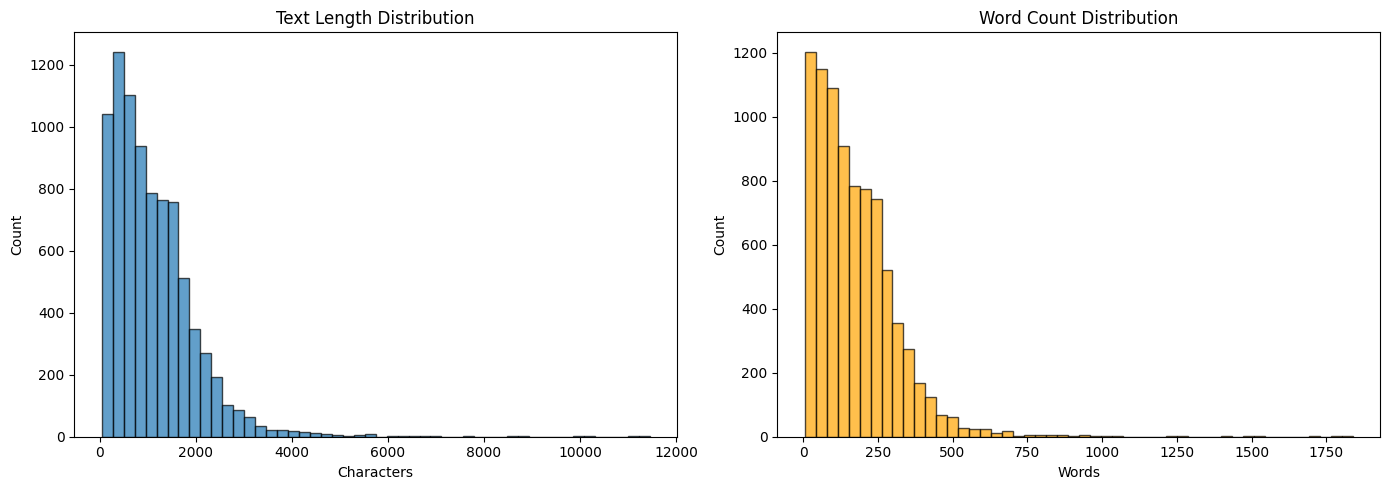

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

train_lengths = [len(text) for text in dataset["train"]["text"]]
stats = pd.Series(train_lengths).describe()
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("Text Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

word_counts = [len(text.split()) for text in dataset["train"]["text"]]
axes[1].hist(word_counts, bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Sanity-check Chunked Forward

In [8]:
import torch
from qlora_scratch.lora import LoRAConfig, ChunkedQuantizedLoRALinear, QuantizedLoRALinear

torch.manual_seed(0)
ref_linear = torch.nn.Linear(256, 384, bias=True).half()
cfg = LoRAConfig(rank=4, alpha=8, dropout=0.0, block_size=64, chunk_size=64)

dense_qlora = QuantizedLoRALinear(ref_linear, cfg)
chunked_qlora = ChunkedQuantizedLoRALinear(ref_linear, cfg)
chunked_qlora.load_state_dict(dense_qlora.state_dict())

x = torch.randn(2, 16, 256, dtype=torch.float16)
with torch.no_grad():
    y_dense = dense_qlora(x)
    y_chunk = chunked_qlora(x)

max_abs_err = (y_dense - y_chunk).abs().max().item()
print(f"Max |dense - chunked| forward error: {max_abs_err:.3e}")
assert max_abs_err < 5e-3, "Chunked forward diverges from dense forward"
print("Chunked forward matches dense forward (within fp16 tolerance).")


Max |dense - chunked| forward error: 1.953e-03
Chunked forward matches dense forward (within fp16 tolerance).


## 3. Run LoRA / QLoRA / Chunked-QLoRA

In [9]:
from qlora_scratch.train import ExperimentConfig

sample_prompts = [
    "### Instruction:\nSummarize QLoRA in plain language for a student.\n\n### Response:\n",
    "### Instruction:\nWhat is the purpose of NF4 quantization in QLoRA?\n\n### Response:\n",
    "### Instruction:\nExplain why streaming the weight matmul in chunks reduces VRAM.\n\n### Response:\n",
]

base_kwargs = dict(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    lora_rank=8,
    lora_alpha=16,
    quant_block_size=64,
    max_train_samples=512,
    max_eval_samples=128,
)

experiments = {
    "scratch_lora_r8": ExperimentConfig(
        method="lora",
        output_dir=str(RESULTS_DIR / "chunked_run" / "scratch_lora_r8"),
        **base_kwargs,
    ),
    "scratch_qlora_r8": ExperimentConfig(
        method="qlora",
        output_dir=str(RESULTS_DIR / "chunked_run" / "scratch_qlora_r8"),
        **base_kwargs,
    ),
    "scratch_qlora_chunked_r8": ExperimentConfig(
        method="qlora_chunked",
        quant_chunk_size=128,
        output_dir=str(RESULTS_DIR / "chunked_run" / "scratch_qlora_chunked_r8"),
        **base_kwargs,
    ),
}

print("Experiments to run:")
for name, cfg in experiments.items():
    print(name, "method=", cfg.method, "rank=", cfg.lora_rank, "output=", cfg.output_dir)


Experiments to run:
scratch_lora_r8 method= lora rank= 8 output= /content/Quantized-LoRA/results/chunked_run/scratch_lora_r8
scratch_qlora_r8 method= qlora rank= 8 output= /content/Quantized-LoRA/results/chunked_run/scratch_qlora_r8
scratch_qlora_chunked_r8 method= qlora_chunked rank= 8 output= /content/Quantized-LoRA/results/chunked_run/scratch_qlora_chunked_r8


In [10]:
import gc
import json
from pathlib import Path
import torch
from qlora_scratch.train import run_experiment

all_metrics = []

for exp_name, config in experiments.items():
    print("\n" + "#" * 70)
    print(f"Running {exp_name} (method={config.method})")
    print("#" * 70)
    metrics = run_experiment(PROJECT_ROOT / "data", config, sample_prompts=sample_prompts)
    metrics["experiment"] = exp_name
    Path(config.output_dir).mkdir(parents=True, exist_ok=True)
    (Path(config.output_dir) / "metrics.json").write_text(json.dumps(metrics, indent=2))
    all_metrics.append(metrics)
    print(
        f"Done: {exp_name} | eval_loss={metrics['eval_loss']:.4f} "
        f"| peak_vram_mb={metrics['peak_vram_mb']:.1f} "
        f"| tokens/s={metrics['tokens_per_second']:.1f}"
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

len(all_metrics)



######################################################################
Running scratch_lora_r8 (method=lora)
######################################################################


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Epoch 1/1:   0%|          | 0/256 [00:00<?, ?it/s]

Done: scratch_qlora_chunked_r8 | eval_loss=1.4037 | peak_vram_mb=3081.7 | tokens/s=257.6


3

## 4. Three-Way Summary Table

In [11]:
from qlora_scratch.analysis import results_summary_table

summary = results_summary_table(all_metrics)
display_cols = [
    "experiment",
    "method",
    "lora_rank",
    "eval_loss",
    "perplexity",
    "peak_vram_mb",
    "peak_reserved_vram_mb",
    "tokens_per_second",
    "wall_time_s",
]
summary[display_cols]


,experiment,method,lora_rank,eval_loss,perplexity,peak_vram_mb,peak_reserved_vram_mb,tokens_per_second,wall_time_s
0,scratch_lora_r8,lora,8,1.363680,3.910558,3680.354004,3912.0,2238.915714,46.263912
1,scratch_qlora_r8,qlora,8,1.403908,4.071080,4714.229004,4978.0,1876.170655,55.208730
2,scratch_qlora_chunked_r8,qlora_chunked,8,1.403693,4.070205,3081.729004,3244.0,257.649875,402.022318


## 5. VRAM, Throughput, Training Time

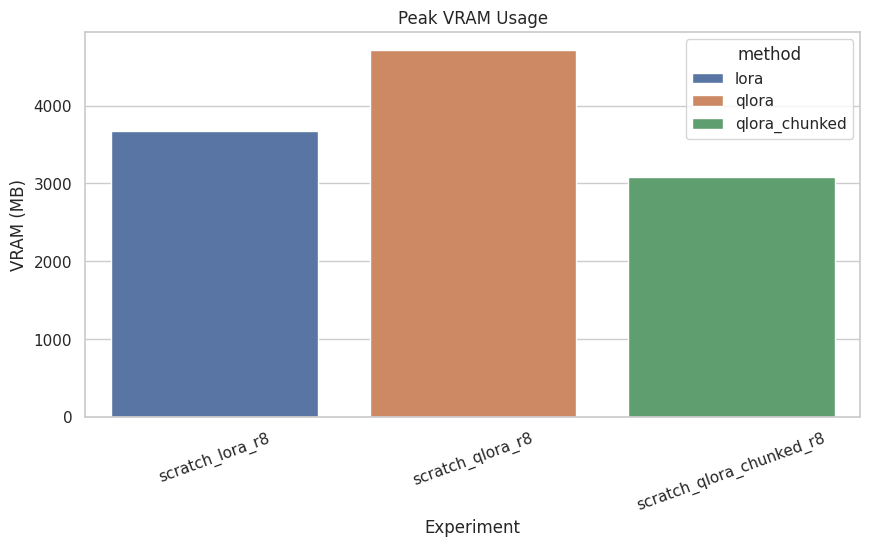

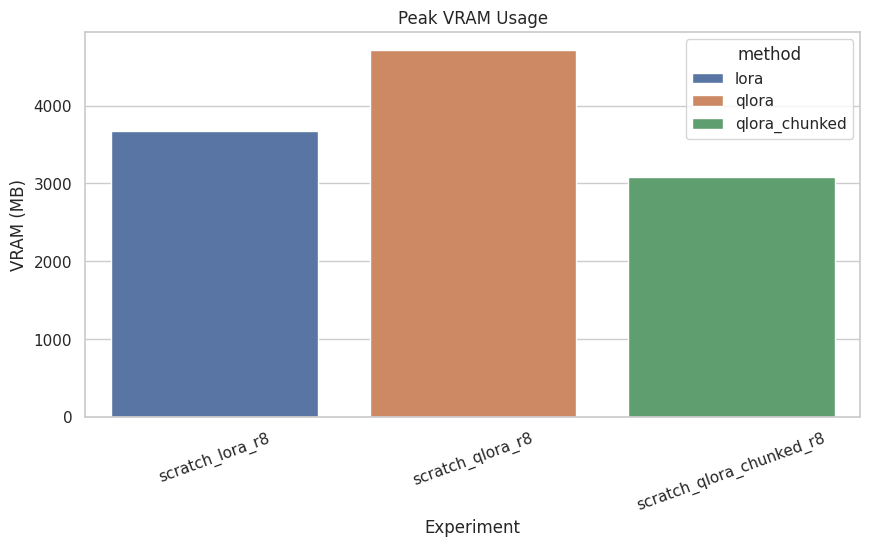

In [12]:
from qlora_scratch.analysis import (
    plot_throughput_comparison,
    plot_training_time_comparison,
    plot_vram_comparison,
)

plot_vram_comparison(summary)


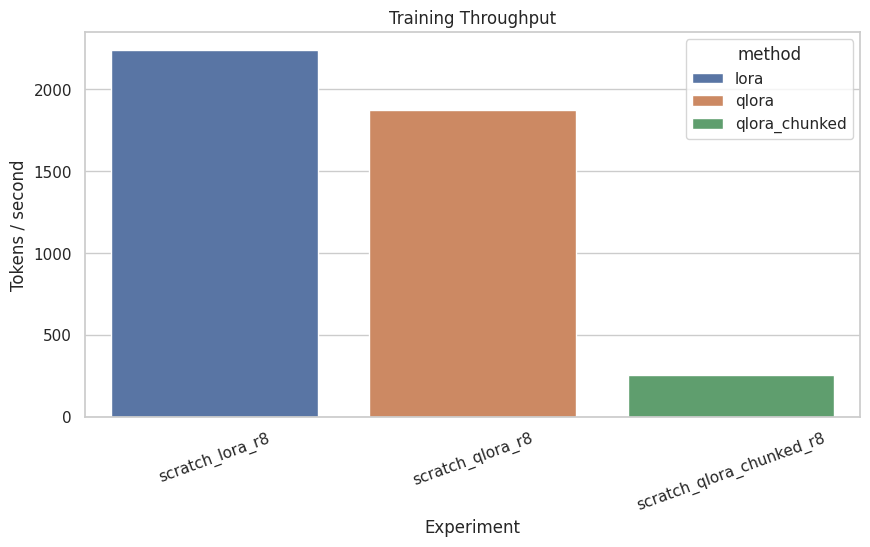

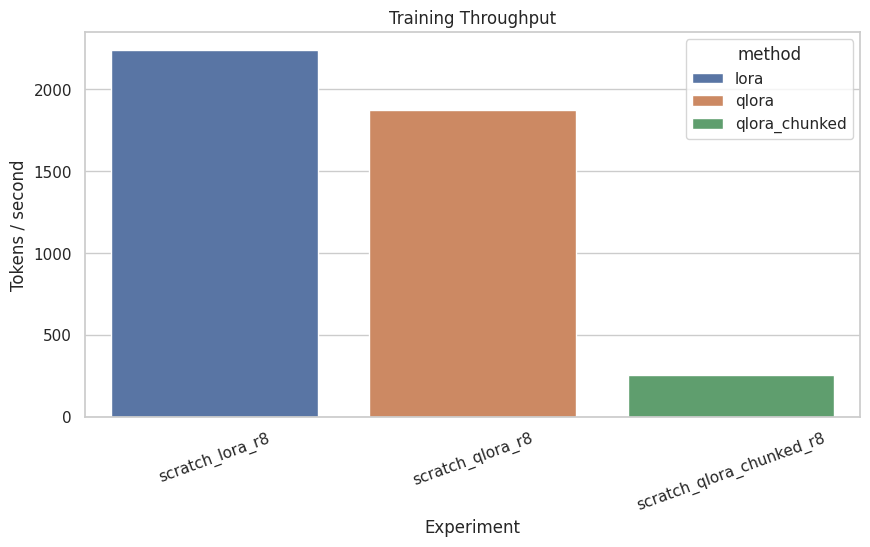

In [13]:
plot_throughput_comparison(summary)


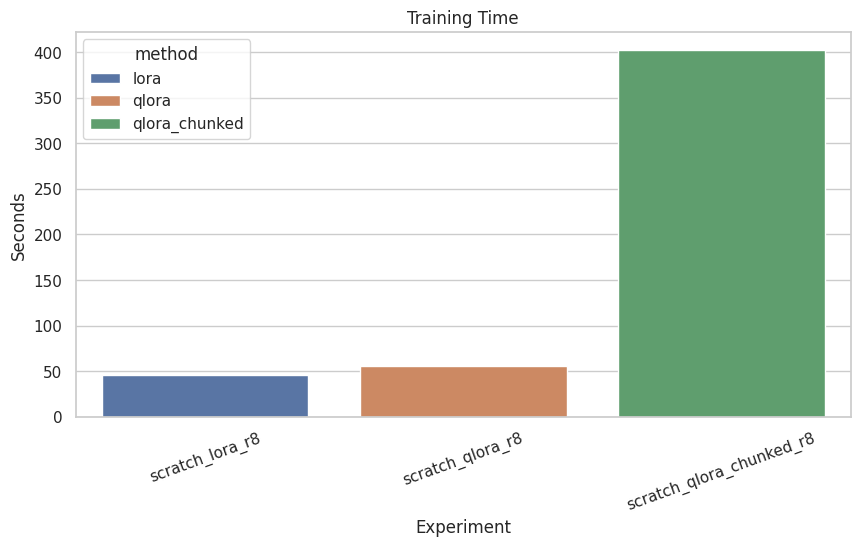

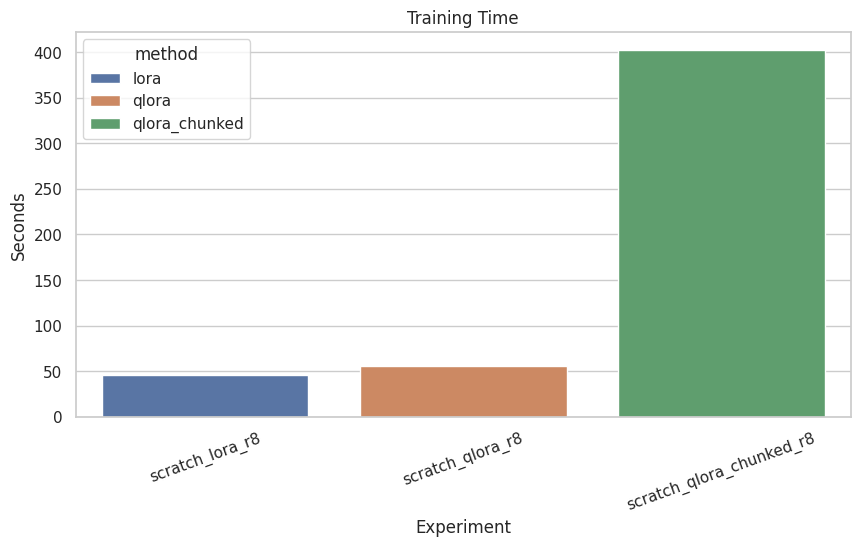

In [14]:
plot_training_time_comparison(summary)


## 6. Training Loss Curves

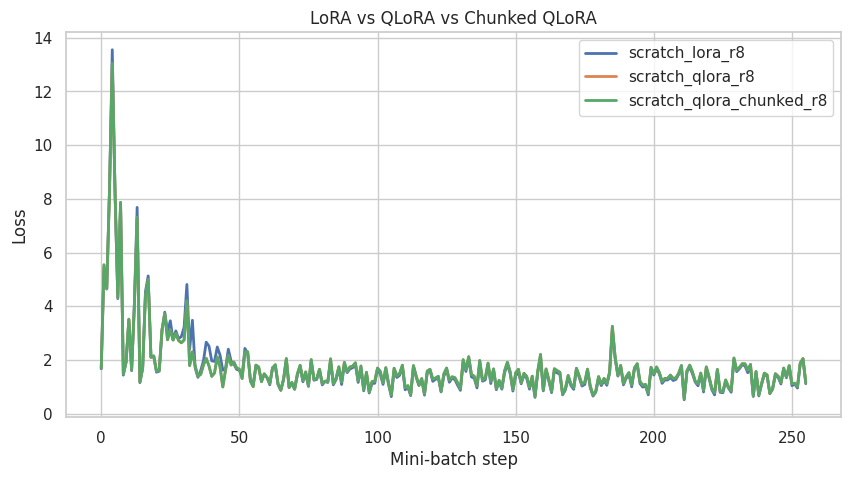

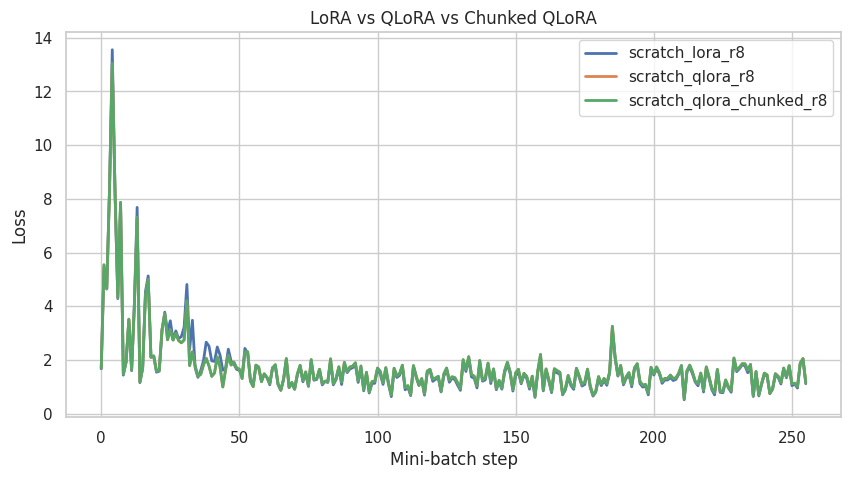

In [15]:
from qlora_scratch.analysis import plot_training_loss

plot_training_loss(all_metrics, title="LoRA vs QLoRA vs Chunked QLoRA")


## 7. Peak VRAM Deltas (Expect Chunked < LoRA < QLoRA)

In [16]:
import pandas as pd

vram_pivot = summary.set_index("method")[["peak_vram_mb", "peak_reserved_vram_mb"]]
vram_pivot["vs_lora_pct"] = (
    (vram_pivot["peak_vram_mb"] - vram_pivot.loc["lora", "peak_vram_mb"])
    / vram_pivot.loc["lora", "peak_vram_mb"]
    * 100.0
)
vram_pivot.round(2)


,peak_vram_mb,peak_reserved_vram_mb,vs_lora_pct
method,,,
lora,3680.35,3912.0,0.00
qlora,4714.23,4978.0,28.09
qlora_chunked,3081.73,3244.0,-16.27


## 8. Pre/Post Instruction-Tuning Samples (Chunked QLoRA Run)

In [17]:
from qlora_scratch.analysis import build_instruction_tuning_table

chunked_metrics = next(m for m in all_metrics if m["method"] == "qlora_chunked")
instruction_table = build_instruction_tuning_table(chunked_metrics)
instruction_table


,prompt_id,prompt,pre_response,post_response,pre_latency_s,post_latency_s,pre_tokens_per_second,post_tokens_per_second
0,1,### Instruction:\nSummarize QLoRA in plain lan...,### Instruction:\nSummarize QLoRA in plain lan...,### Instruction:\nSummarize QLoRA in plain lan...,32.449334,57.888472,1.386777,1.381968
1,2,### Instruction:\nWhat is the purpose of NF4 q...,### Instruction:\nWhat is the purpose of NF4 q...,### Instruction:\nWhat is the purpose of NF4 q...,56.233891,57.758976,1.387064,1.385066
2,3,### Instruction:\nExplain why streaming the we...,### Instruction:\nExplain why streaming the we...,### Instruction:\nExplain why streaming the we...,57.805110,57.965044,1.383961,1.380142


In [18]:
for row in instruction_table.to_dict(orient="records"):
    print(f"=== PROMPT {row['prompt_id']} ===")
    print(row["prompt"])
    print("\n--- PRE-FINETUNE ---")
    print(row["pre_response"])
    print("\n--- POST-FINETUNE ---")
    print(row["post_response"])
    print("\n")


=== PROMPT 1 ===
### Instruction:
Summarize QLoRA in plain language for a student.

### Response:


--- PRE-FINETUNE ---
### Instruction:
Summarize QLoRA in plain language for a student.

### Response:
QLoRA is a program that helps students learn and practice math concepts through interactive games and activities. It provides a fun and engaging way for students to learn math concepts, and it can help improve their math skills.

--- POST-FINETUNE ---
### Instruction:
Summarize QLoRA in plain language for a student.

### Response:
QLoRA is a program that helps students learn and practice the skills they need to succeed in college and beyond. It offers a variety of resources, including interactive lessons, quizzes, and practice tests, to help students improve their academic skills. QLoRA also provides personalized feedback on their progress, helping students to identify areas where they need to improve and to set goals for their learning


=== PROMPT 2 ===
### Instruction:
What is the pur

### New Experiment Matrix 3x3 with new Visualizations.

In [19]:
from qlora_scratch.train import ExperimentConfig

sample_prompts = [
    "### Instruction:\nSummarize QLoRA in plain language for a student.\n\n### Response:\n",
    "### Instruction:\nWhat is the purpose of NF4 quantization in QLoRA?\n\n### Response:\n",
    "### Instruction:\nExplain why streaming the weight matmul in chunks reduces VRAM.\n\n### Response:\n",
]

ranks = [8, 16, 32]
methods = ["lora", "qlora", "qlora_chunked"]

base_kwargs = dict(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quant_block_size=64,
    max_train_samples=512,
    max_eval_samples=128,
)

experiments = {}
for rank in ranks:
    for method in methods:
        name = f"scratch_{method}_r{rank}"
        kwargs = dict(
            method=method,
            lora_rank=rank,
            lora_alpha=rank * 2,
            output_dir=str(RESULTS_DIR / "rank_sweep" / name),
            **base_kwargs,
        )
        if method == "qlora_chunked":
            kwargs["quant_chunk_size"] = 128
        experiments[name] = ExperimentConfig(**kwargs)

print(f"Total experiments to run: {len(experiments)}")
for name, cfg in experiments.items():
    print(f"  {name:32s} method={cfg.method:14s} rank={cfg.lora_rank}")


Total experiments to run: 9
  scratch_lora_r8                  method=lora           rank=8
  scratch_qlora_r8                 method=qlora          rank=8
  scratch_qlora_chunked_r8         method=qlora_chunked  rank=8
  scratch_lora_r16                 method=lora           rank=16
  scratch_qlora_r16                method=qlora          rank=16
  scratch_qlora_chunked_r16        method=qlora_chunked  rank=16
  scratch_lora_r32                 method=lora           rank=32
  scratch_qlora_r32                method=qlora          rank=32
  scratch_qlora_chunked_r32        method=qlora_chunked  rank=32


In [20]:
import gc, json
from pathlib import Path
import torch
from qlora_scratch.train import run_experiment

all_metrics = []
for exp_name, config in experiments.items():
    print("\n" + "#" * 78)
    print(f"# {exp_name}  (method={config.method}, rank={config.lora_rank})")
    print("#" * 78)
    metrics = run_experiment(PROJECT_ROOT / "data", config, sample_prompts=sample_prompts)
    metrics["experiment"] = exp_name
    Path(config.output_dir).mkdir(parents=True, exist_ok=True)
    (Path(config.output_dir) / "metrics.json").write_text(json.dumps(metrics, indent=2))
    all_metrics.append(metrics)
    print(
        f"  -> eval_loss={metrics['eval_loss']:.4f}  "
        f"peak_vram={metrics['peak_vram_mb']:.1f} MB  "
        f"tokens/s={metrics['tokens_per_second']:.1f}  "
        f"wall={metrics['wall_time_s']:.1f}s"
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nFinished {len(all_metrics)} experiments.")



##############################################################################
# scratch_lora_r8  (method=lora, rank=8)
##############################################################################


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/256 [00:00<?, ?it/s]

  -> eval_loss=1.3637  peak_vram=3679.4 MB  tokens/s=2189.6  wall=47.3s

##############################################################################
# scratch_qlora_r8  (method=qlora, rank=8)
##############################################################################


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Epoch 1/1:   0%|          | 0/256 [00:00<?, ?it/s]

  -> eval_loss=1.3706  peak_vram=4791.0 MB  tokens/s=1770.9  wall=58.5s

##############################################################################
# scratch_qlora_chunked_r32  (method=qlora_chunked, rank=32)
##############################################################################


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/256 [00:00<?, ?it/s]

  -> eval_loss=1.3707  peak_vram=3158.5 MB  tokens/s=253.3  wall=408.9s

Finished 9 experiments.


In [21]:
import pandas as pd
from qlora_scratch.analysis import results_summary_table

summary = results_summary_table(all_metrics)
display_cols = [
    "experiment", "method", "lora_rank",
    "eval_loss", "perplexity",
    "peak_vram_mb", "peak_reserved_vram_mb",
    "tokens_per_second", "avg_generation_tokens_per_second",
    "avg_optimizer_step_latency_s", "wall_time_s",
]
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary[display_cols].sort_values(["lora_rank", "method"]).reset_index(drop=True)


,experiment,method,lora_rank,eval_loss,perplexity,peak_vram_mb,peak_reserved_vram_mb,tokens_per_second,avg_generation_tokens_per_second,avg_optimizer_step_latency_s,wall_time_s
0,scratch_lora_r8,lora,8,1.364,3.911,3679.354,3870.000,2189.593,21.675,0.317,47.306
1,scratch_qlora_r8,qlora,8,1.404,4.071,4714.229,4978.000,1878.142,12.594,0.345,55.151
2,scratch_qlora_chunked_r8,qlora_chunked,8,1.404,4.070,3081.729,3244.000,257.299,1.362,1.701,402.571
3,scratch_lora_r16,lora,16,1.352,3.867,3704.620,3896.000,2105.642,21.494,0.358,49.192
4,scratch_qlora_r16,qlora,16,1.384,3.990,4740.745,5004.000,1796.137,12.687,0.393,57.669
5,scratch_qlora_chunked_r16,qlora_chunked,16,1.384,3.990,3106.995,3270.000,253.395,1.363,1.761,408.773
6,scratch_lora_r32,lora,32,1.343,3.831,3737.901,3984.000,2073.611,21.481,0.400,49.952
7,scratch_qlora_r32,qlora,32,1.371,3.938,4791.026,5014.000,1770.930,12.693,0.436,58.490
8,scratch_qlora_chunked_r32,qlora_chunked,32,1.371,3.938,3158.526,3292.000,253.309,1.365,1.809,408.912


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

METHOD_ORDER = ["lora", "qlora", "qlora_chunked"]
METHOD_LABELS = {
    "lora": "LoRA",
    "qlora": "QLoRA (dense dequant)",
    "qlora_chunked": "QLoRA (chunked)",
}
METHOD_COLORS = {
    "lora": "#33658A",          # steel blue
    "qlora": "#BC4B51",          # coral red
    "qlora_chunked": "#5B8E7D",  # forest green
}
RANK_LINESTYLES = {8: "solid", 16: (0, (4, 2)), 32: (0, (1, 1.5))}
RANK_MARKERS = {8: "o", 16: "s", 32: "^"}

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelweight": "semibold",
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "#cccccc",
    "figure.dpi": 110,
})

def grouped_bar(summary, metric, ylabel, title, fmt="{:.0f}"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ranks = sorted(summary["lora_rank"].unique())
    width = 0.8 / len(METHOD_ORDER)
    x = np.arange(len(ranks))

    for i, method in enumerate(METHOD_ORDER):
        sub = summary[summary["method"] == method].set_index("lora_rank").reindex(ranks)
        values = sub[metric].values
        offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
        bars = ax.bar(
            x + offset, values, width,
            label=METHOD_LABELS[method],
            color=METHOD_COLORS[method],
            edgecolor="white", linewidth=0.8,
        )
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.annotate(
                    fmt.format(val),
                    xy=(bar.get_x() + bar.get_width() / 2, val),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f"r = {r}" for r in ranks])
    ax.set_xlabel("LoRA rank")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="Method", loc="best")
    ax.margins(y=0.18)
    fig.tight_layout()
    return fig

print("Style configured.")


Style configured.


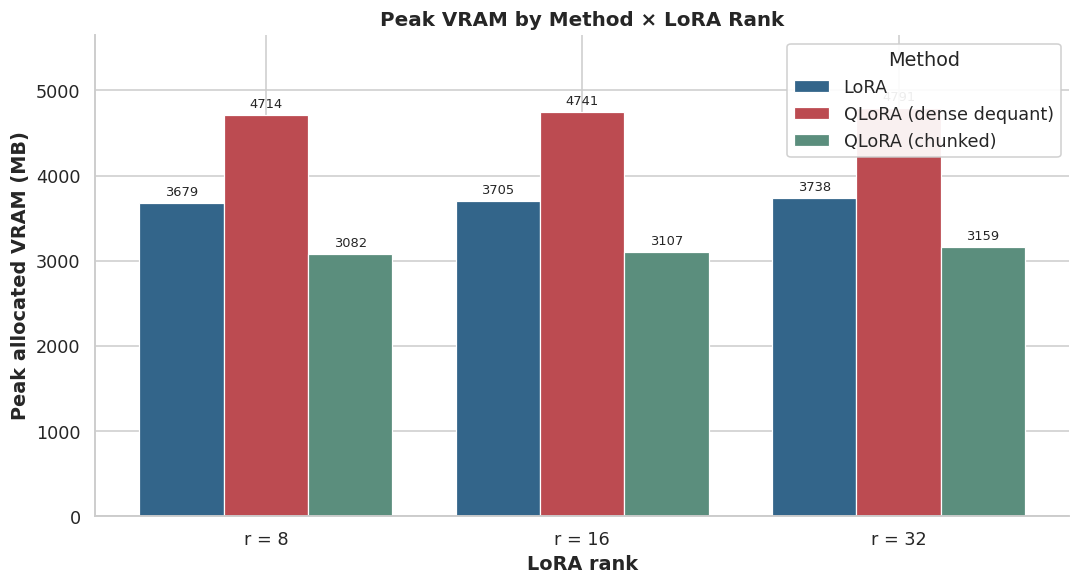

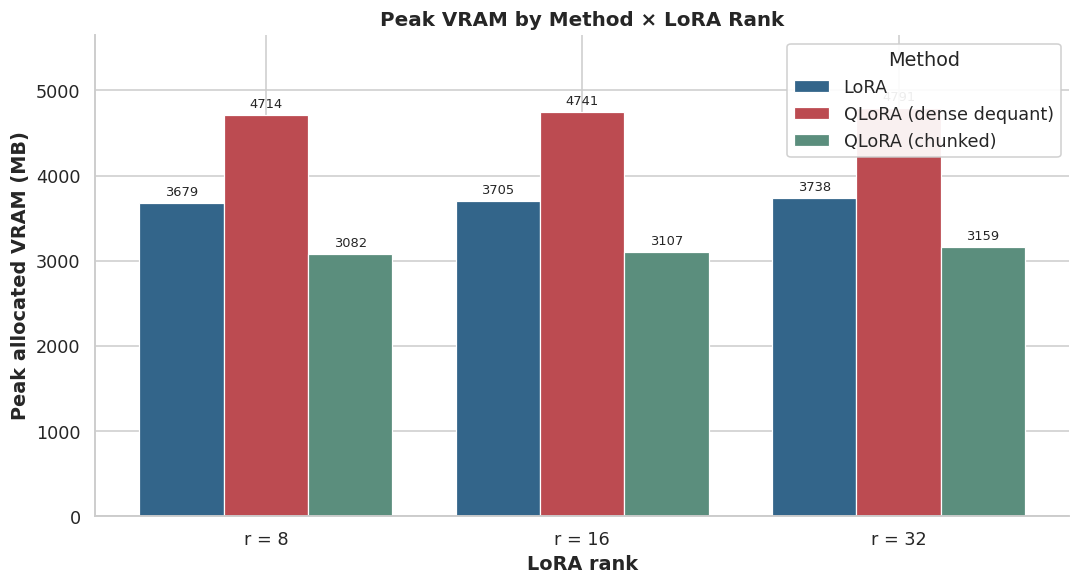

In [23]:
fig = grouped_bar(
    summary,
    metric="peak_vram_mb",
    ylabel="Peak allocated VRAM (MB)",
    title="Peak VRAM by Method × LoRA Rank",
    fmt="{:.0f}",
)
fig


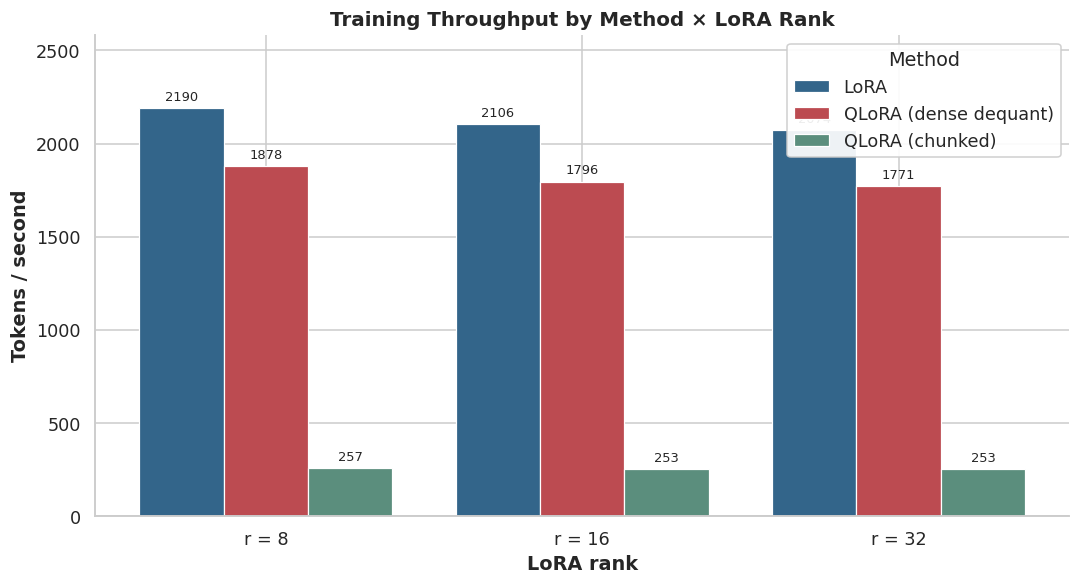

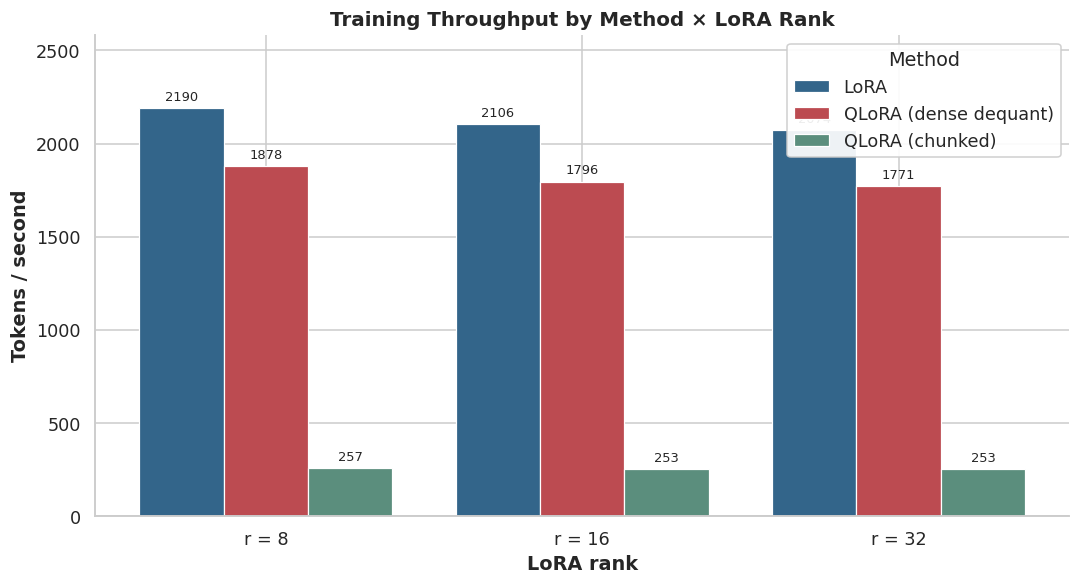

In [24]:
fig = grouped_bar(
    summary,
    metric="tokens_per_second",
    ylabel="Tokens / second",
    title="Training Throughput by Method × LoRA Rank",
    fmt="{:.0f}",
)
fig


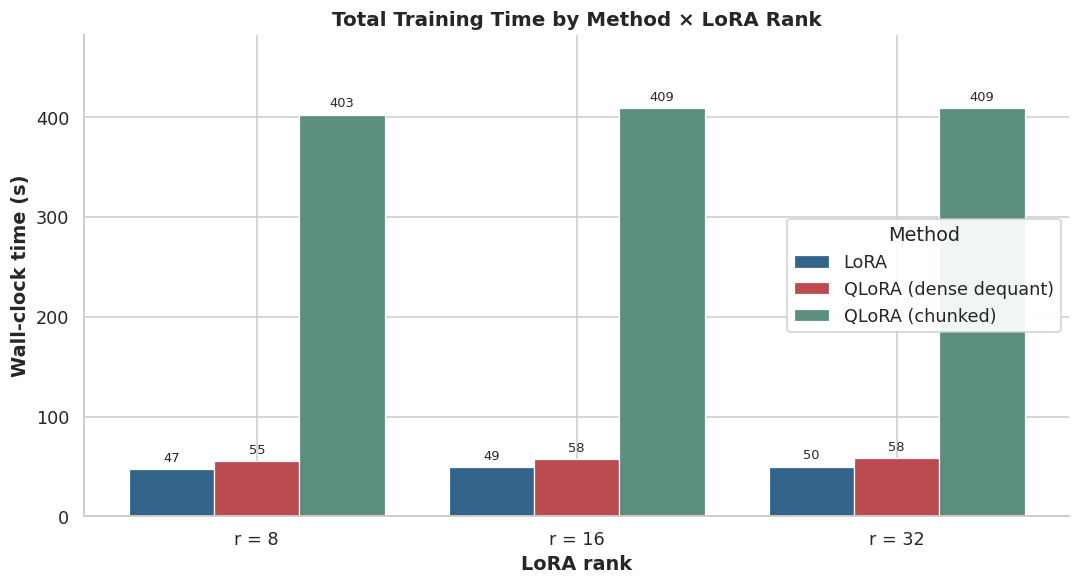

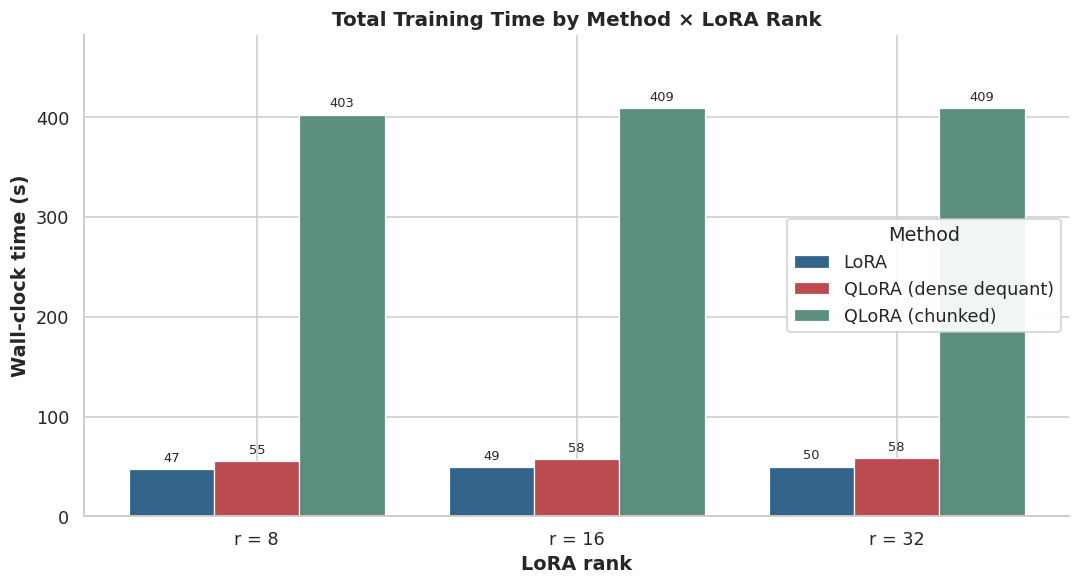

In [25]:
fig = grouped_bar(
    summary,
    metric="wall_time_s",
    ylabel="Wall-clock time (s)",
    title="Total Training Time by Method × LoRA Rank",
    fmt="{:.0f}",
)
fig


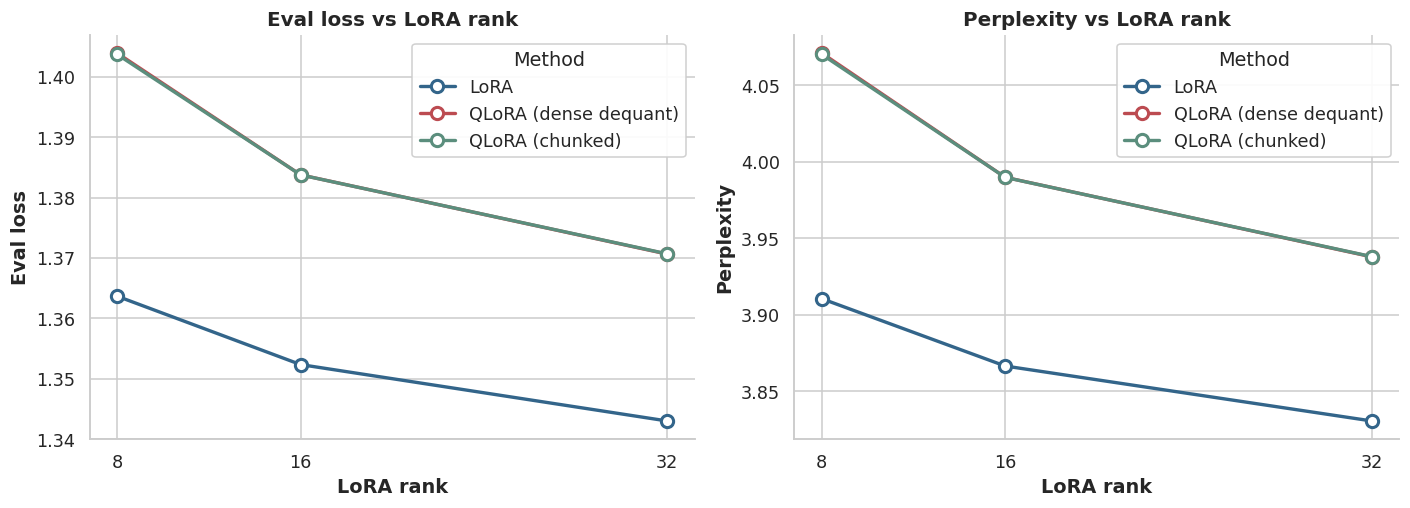

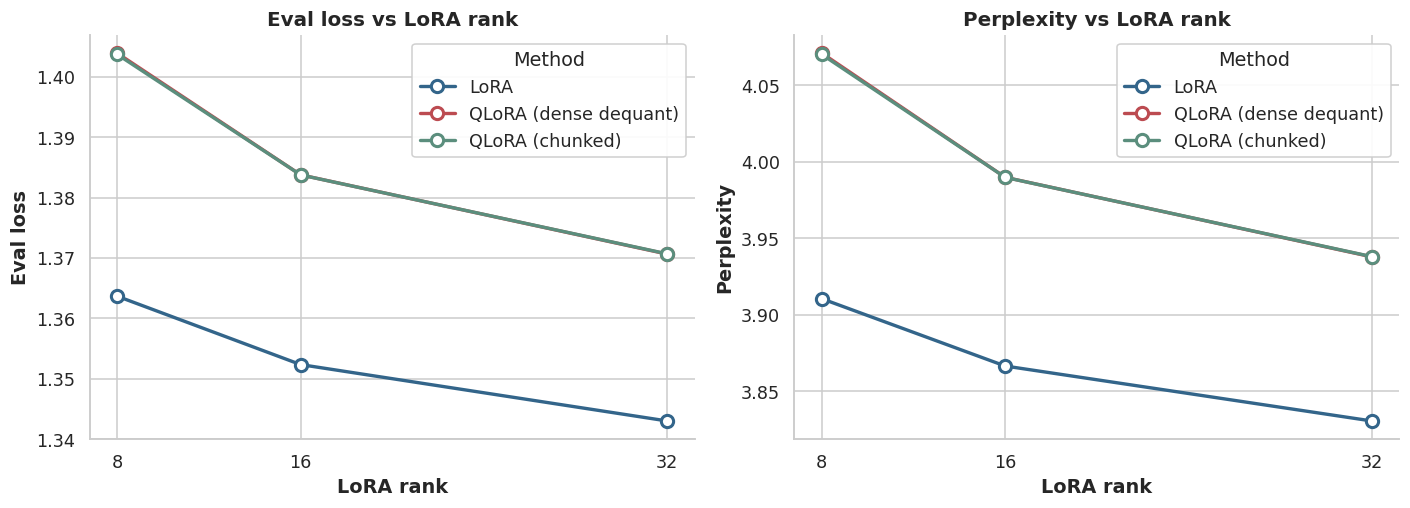

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

for metric, label, ax in [("eval_loss", "Eval loss", axes[0]),
                          ("perplexity", "Perplexity", axes[1])]:
    for method in METHOD_ORDER:
        sub = summary[summary["method"] == method].sort_values("lora_rank")
        ax.plot(
            sub["lora_rank"], sub[metric],
            label=METHOD_LABELS[method],
            color=METHOD_COLORS[method],
            linewidth=2.2, marker="o", markersize=8,
            markerfacecolor="white", markeredgewidth=2,
        )
    ax.set_xticks(sorted(summary["lora_rank"].unique()))
    ax.set_xlabel("LoRA rank")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs LoRA rank")
    ax.legend(title="Method", loc="best")

fig.tight_layout()
fig


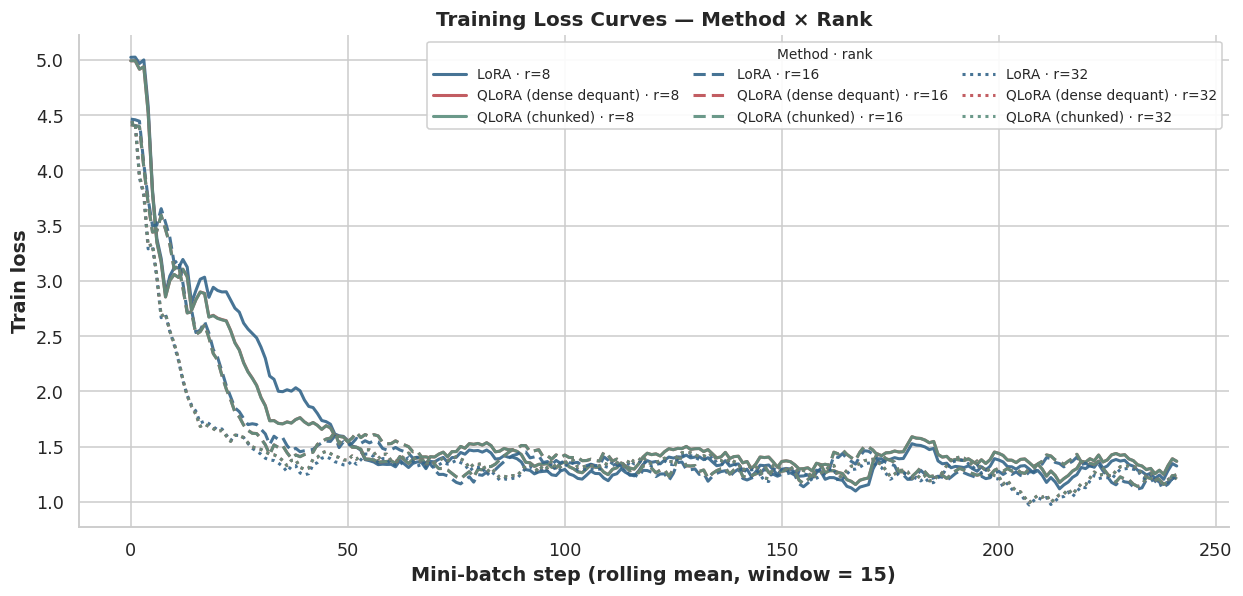

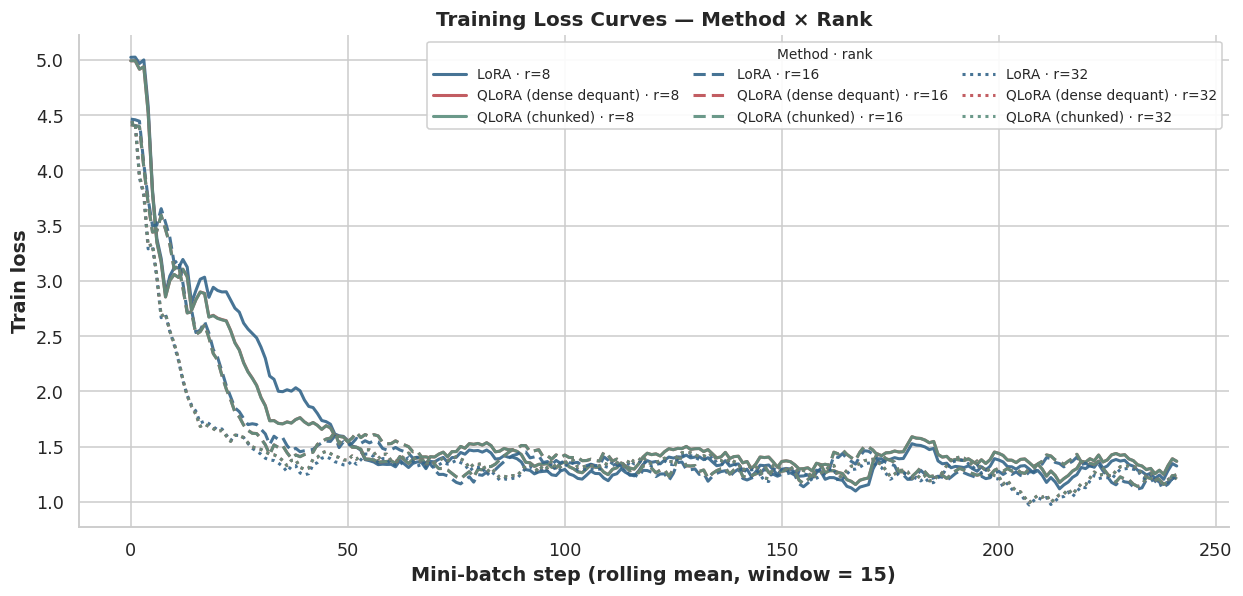

In [27]:
def smooth(values, window=15):
    arr = np.asarray(values, dtype=float)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode="valid")

fig, ax = plt.subplots(figsize=(11.5, 5.6))

for metrics in all_metrics:
    method = metrics["config"]["method"]
    rank = metrics["config"]["lora_rank"]
    curve = smooth(metrics["train_loss_curve"], window=15)
    ax.plot(
        np.arange(len(curve)),
        curve,
        color=METHOD_COLORS[method],
        linestyle=RANK_LINESTYLES[rank],
        linewidth=2.0,
        alpha=0.9,
        label=f"{METHOD_LABELS[method]} · r={rank}",
    )

ax.set_xlabel("Mini-batch step (rolling mean, window = 15)")
ax.set_ylabel("Train loss")
ax.set_title("Training Loss Curves — Method × Rank")
ax.legend(
    ncol=3, loc="upper right", fontsize=9,
    title="Method · rank", title_fontsize=9,
    columnspacing=1.0, handlelength=2.4,
)
fig.tight_layout()
fig


In [28]:
import pandas as pd

pivot = summary.pivot_table(
    index="lora_rank",
    columns="method",
    values=["peak_vram_mb", "tokens_per_second", "wall_time_s", "eval_loss"],
)
print("Aggregate metrics by rank × method:")
print(pivot.round(2).to_string())

vram = summary.pivot(index="lora_rank", columns="method", values="peak_vram_mb")
vs_lora = vram.sub(vram["lora"], axis=0).div(vram["lora"], axis=0).mul(100).round(2)
vs_lora.columns = [f"{c} Δ vs LoRA (%)" for c in vs_lora.columns]
print("\nPeak VRAM delta vs LoRA (negative = lower memory):")
print(vs_lora.to_string())


Aggregate metrics by rank × method:
          eval_loss                     peak_vram_mb                        tokens_per_second                        wall_time_s                     
method         lora qlora qlora_chunked         lora    qlora qlora_chunked              lora    qlora qlora_chunked        lora  qlora qlora_chunked
lora_rank                                                                                                                                            
8             1.360 1.400         1.400     3679.350 4714.230      3081.730          2189.590 1878.140       257.300      47.310 55.150       402.570
16            1.350 1.380         1.380     3704.620 4740.740      3106.990          2105.640 1796.140       253.390      49.190 57.670       408.770
32            1.340 1.370         1.370     3737.900 4791.030      3158.530          2073.610 1770.930       253.310      49.950 58.490       408.910

Peak VRAM delta vs LoRA (negative = lower memory):
           l